{'E': <__main__.CityEnvironment object at 0x00000251F5ABAFE0>, 'ssfpl': <function single_source_dijkstra_path_length at 0x00000251F0330700>, 'msfpl': <function multi_source_dijkstra_path_length at 0x00000251F03308B0>, 'delay_time': 1}
5514 5504 5514


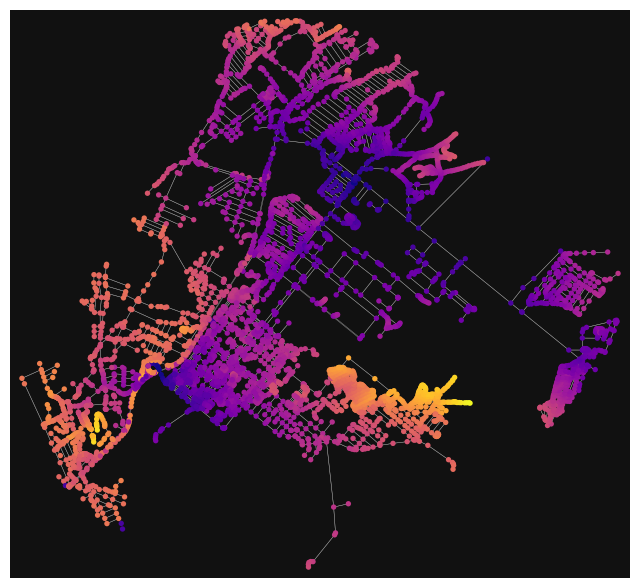

In [1]:
from abc import abstractmethod
from genesis.models import Environment, RoadNetworkGraph, SpeedProfile, DislocationProfile, Computer
from genesis.morphers import MorphersGraph
import networkx as nx
import osmnx as ox

class CityEnvironment(Environment):

    def __init__(self, name='E_City', path='', **attr):
        # Добавление дочерних моделей данных
        self.add_features(
            [
                RoadNetworkGraph(path='test_rng.ml'),
                DislocationProfile(),
                SpeedProfile()
            ]
        )
        super().__init__(name, path, **attr)


# class Computer(object):

#     # Настройки модели компьютера
#     # ssfpl = nx.single_source_dijkstra_path_length
#     # msfpl = nx.multi_source_dijkstra_path_length
#     # delay_time = 1

#     def __init__(self, E:Environment, **kwargs):
#         self.environment = E

#     def set_settings(self, **kwargs):
#         '''Установка настроек модели компьютера
#         '''
#         for k,v in kwargs.items():
#             setattr(self, k, v)
#         return self

#     @property
#     def environment(self):
#         return self.E

#     @environment.setter
#     def environment(self, E:Environment):
#         self.E = E
#         return self
    
#     @abstractmethod
#     def execute(self):
#         # Здесь описывается последовательность выполняемых действий
#         return self
    
class TestComputer(Computer):
    
    def execute(self):
        G = self.E.RNG.G
        MorphersGraph.add_edge_travel_times(G, self.E.SP)
        # gdf_e = ox.graph_to_gdfs(self.E.RNG.G, nodes=False)
        # print(gdf_e.columns)
        nl = list(G.nodes())
        # print(nl)
        lens = self.msfpl(G, [nl[100], nl[1000]])
        lens_full = {node:lens[node] if node in lens else 11 for node in G.nodes()}
        # lens = {k: v if k in nl else 1000 for k,v in lens.items()}
        print(len(nl), len(lens), len(lens_full))
        nx.set_node_attributes(G, lens_full, 'arrival_time')

        nc = ox.plot.get_node_colors_by_attr(G, attr="arrival_time", cmap="plasma")
        ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

        return super().execute()



E = CityEnvironment(path='tests/data/').load()

C = TestComputer(E)
C.set_settings(
    ssfpl = nx.single_source_dijkstra_path_length,
    msfpl = nx.multi_source_dijkstra_path_length,
    delay_time = 1,
)


print(C.__dict__)

C.execute()

In [8]:
C.__dict__['ssfpl']

<function networkx.algorithms.shortest_paths.weighted.single_source_dijkstra_path_length(G, source, cutoff=None, weight='weight')>

In [7]:
C.execute()

Index(['osmid', 'oneway', 'lanes', 'ref', 'highway', 'maxspeed', 'reversed',
       'length', 'travel_time', 'name', 'bridge', 'service', 'access',
       'tunnel', 'geometry'],
      dtype='object')


In [1]:
from genesis.models import Environment, RoadNetworkGraph, SpeedProfile, DislocationProfile, Computer
from genesis.morphers import MorphersDP
import networkx as nx
import osmnx as ox


DP = DislocationProfile().load(base_path='tests/data/')
RNG = RoadNetworkGraph(path='test_rng.ml').load(base_path='tests/data/')

dp = DP.get
dp

,description,type,class,geometry
name,,,,
ОП ПСЧ-1,Тестовая ПСЧ,ФПС,ОП,POINT (10393466.563 7586594.593)
ПСЧ-1,Тестовая ПСЧ,ФПС,ПСЧ,POINT (10390523.527 7581468.014)


In [3]:
for node, distance, unit in zip(*ox.distance.nearest_nodes(RNG.G, dp.geometry.x, dp.geometry.y, return_dist=True), dp.index):
    print(node, distance, unit)

2034402701 18727907.071512394 ОП ПСЧ-1
5574211404 13254900.945561742 ПСЧ-1


In [4]:
MorphersDP.add_nearest_node(DP, RNG)

ValueError: Found array with 0 sample(s) (shape=(0, 2)) while a minimum of 1 is required.